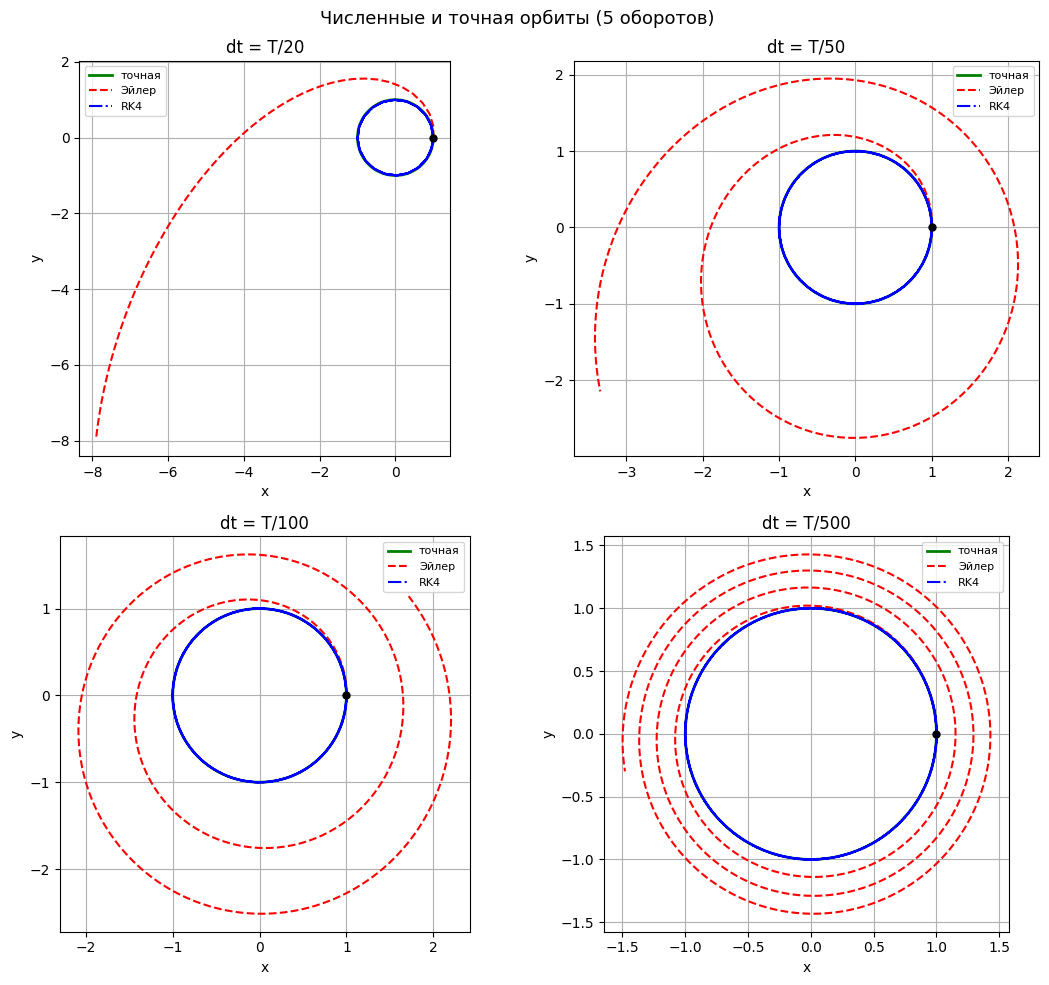

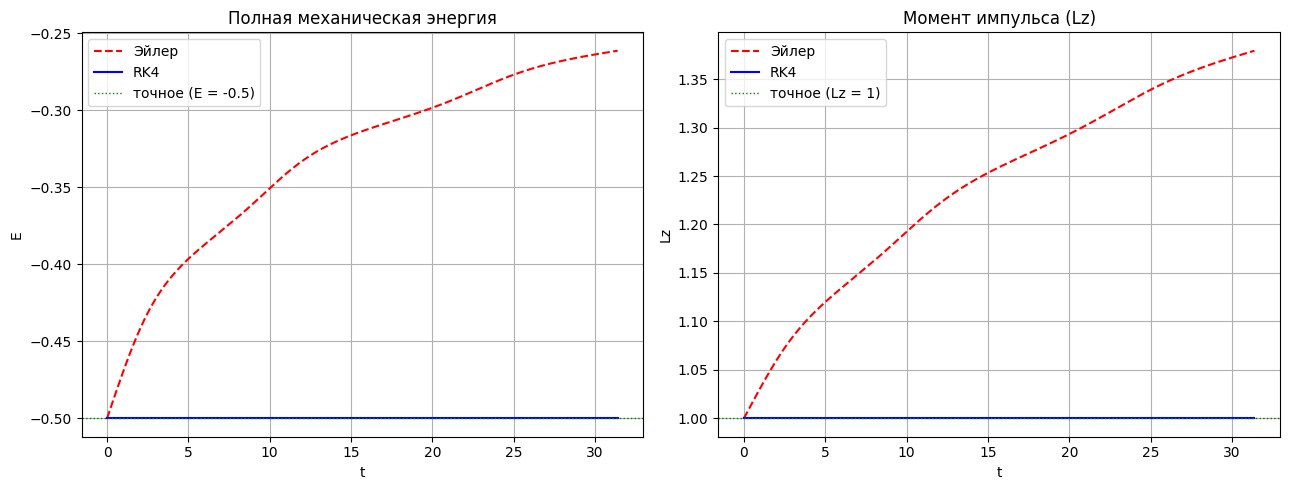

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Параметры задачи

r0 = np.array([1.0, 0.0])        # начальное положение
v0 = np.array([0.0, 1.0])        # начальная скорость

T = 2 * np.pi                     # период обращения
t_start = 0.0
t_end = 5 * T                     # 5 полных оборотов


# Точное решение

def exact_orbit(t):
    return np.cos(t), np.sin(t)


def exact_velocity(t):
    return -np.sin(t), np.cos(t)


# Правая часть системы ОДУ
#   dr/dt = v
#   dv/dt = -r / |r|^3

def derivatives(r, v):
    """
    r - вектор положения (2D)
    v - вектор скорости (2D)
    """
    dist = np.sqrt(r[0]**2 + r[1]**2)
    dr = v
    dv = -r / dist**3
    return dr, dv


# Метод Эйлера

def solve_euler(r0, v0, time):
    """
    r0   - начальное положение (массив длины 2)
    v0   - начальная скорость (массив длины 2)
    time - массив моментов времени
    """
    N = len(time)
    dt = time[1] - time[0]

    r = np.zeros((N, 2))
    v = np.zeros((N, 2))

    r[0] = r0
    v[0] = v0

    for i in range(N - 1):
        dr, dv = derivatives(r[i], v[i])
        r[i+1] = r[i] + dt * dr
        v[i+1] = v[i] + dt * dv

    return r, v


# Метод Рунге-Кутты 4-го порядка

def solve_rk4(r0, v0, time):
    """
    r0   - начальное положение (массив длины 2)
    v0   - начальная скорость (массив длины 2)
    time - массив моментов времени
    """
    N = len(time)
    dt = time[1] - time[0]

    r = np.zeros((N, 2))
    v = np.zeros((N, 2))

    r[0] = r0
    v[0] = v0

    for i in range(N - 1):
        ri = r[i]
        vi = v[i]

        # k1
        k1r, k1v = derivatives(ri, vi)

        # k2
        k2r, k2v = derivatives(ri + 0.5*dt*k1r, vi + 0.5*dt*k1v)

        # k3
        k3r, k3v = derivatives(ri + 0.5*dt*k2r, vi + 0.5*dt*k2v)

        # k4
        k4r, k4v = derivatives(ri + dt*k3r, vi + dt*k3v)

        r[i+1] = ri + (dt / 6.0) * (k1r + 2*k2r + 2*k3r + k4r)
        v[i+1] = vi + (dt / 6.0) * (k1v + 2*k2v + 2*k3v + k4v)

    return r, v


# Полная механическая энергия и момент импульса

def energy(r, v):
    """E = v^2/2 - 1/|r|"""
    speed2 = v[:, 0]**2 + v[:, 1]**2
    dist = np.sqrt(r[:, 0]**2 + r[:, 1]**2)
    return 0.5 * speed2 - 1.0 / dist


def angular_momentum(r, v):
    """Lz = x*vy - y*vx"""
    return r[:, 0] * v[:, 1] - r[:, 1] * v[:, 0]


# Сравнение орбит для нескольких шагов

def plot_orbits():
    steps = [T / 20, T / 50, T / 100, T / 500]

    fig, axes = plt.subplots(2, 2, figsize=(11, 10))

    # точная орбита
    phi = np.linspace(0, 2*np.pi, 300)
    x_ex, y_ex = np.cos(phi), np.sin(phi)

    for ax, dt in zip(axes.flat, steps):
        time = np.arange(t_start, t_end, dt)

        r_e, _ = solve_euler(r0, v0, time)
        r_r, _ = solve_rk4(r0, v0, time)

        ax.plot(x_ex, y_ex, 'g', lw=2, label='точная')
        ax.plot(r_e[:, 0], r_e[:, 1], 'r--', label='Эйлер')
        ax.plot(r_r[:, 0], r_r[:, 1], 'b-.', label='RK4')
        ax.plot(r0[0], r0[1], 'ko', ms=5)

        ax.set_title(f'dt = T/{int(round(T / dt))}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_aspect('equal')
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.suptitle('Численные и точная орбиты (5 оборотов)', fontsize=13)
    plt.tight_layout()
    plt.show()


# Графики сохранения энергии и момента импульса

def plot_integrals():
    dt = T / 200
    time = np.arange(t_start, t_end, dt)

    r_e, v_e = solve_euler(r0, v0, time)
    r_r, v_r = solve_rk4(r0, v0, time)

    # для круговой орбиты: E = -0.5, Lz = 1.0
    E_euler = energy(r_e, v_e)
    E_rk4   = energy(r_r, v_r)

    Lz_euler = angular_momentum(r_e, v_e)
    Lz_rk4   = angular_momentum(r_r, v_r)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # полная энергия
    axes[0].plot(time, E_euler, 'r--', label='Эйлер')
    axes[0].plot(time, E_rk4,   'b-',  label='RK4')
    axes[0].axhline(-0.5, color='g', ls=':', lw=1, label='точное (E = -0.5)')
    axes[0].set_title('Полная механическая энергия')
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('E')
    axes[0].grid(True)
    axes[0].legend()

    # момент импульса
    axes[1].plot(time, Lz_euler, 'r--', label='Эйлер')
    axes[1].plot(time, Lz_rk4,   'b-',  label='RK4')
    axes[1].axhline(1.0, color='g', ls=':', lw=1, label='точное (Lz = 1)')
    axes[1].set_title('Момент импульса (Lz)')
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('Lz')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_orbits()
plot_integrals()
